In [1]:
# ==========================================
# PART 1: ENVIRONMENT & LOGIC
# ==========================================
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

class CareerMobilityEnv(gym.Env):
    """
    OpenEnv Specification: Indian Career Mobility (Tier 1-5)
    This environment models the 'Prestige Penalty' and 'Debt Trap'
    inherent in the Indian educational system.
    """
    def __init__(self):
        super(CareerMobilityEnv, self).__init__()
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(low=-1000, high=1000, shape=(6,), dtype=np.float32)
        self.reset()

    def _get_salary(self, tier, collar):
        # Data synthesized from PLFS & NASSCOM India Skill Reports
        base = {0: 18, 1: 30, 2: 55, 3: 110, 4: 300}
        multiplier = {1: 2.2, 2: 1.6, 3: 1.3, 4: 1.1, 5: 0.9}
        return base[int(collar)] * multiplier[int(tier)]

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Starting State: Tier 5 Graduate, 200k Debt, 50k Savings
        self.state = np.array([5.0, 0.0, 50.0, 200.0, 0.0, 0.0], dtype=np.float32)
        self.months = 0
        return self.state, {}

    def step(self, action):
        tier, skills, savings, debt, exp, collar = self.state
        self.months += 1
        reward = 0
        done = False

        savings -= 15 # Monthly Burn Rate (Tier-1 City Expenses)

        if action == 0: # WORK
            savings += self._get_salary(tier, collar)
            exp += 1
            reward += 2
        elif action == 1: # UPSKILL (Reward-Shaped for mobility)
            savings -= 30
            skills = min(100, skills + 12)
            reward += 15 # Reward Shaping: Incentive for human capital growth
        elif action == 2: # NETWORK
            savings -= 5
            skills = min(100, skills + 3)
            reward += 5
        elif action == 3: # APPLY FOR JUMP
            success_prob = (skills / 100) * (exp / 12 + 1) * (1 / tier) * 1.8
            if np.random.rand() < success_prob:
                collar = min(4, collar + 1)
                reward += 200
            else:
                reward -= 5

        debt += (debt * 0.007) # Education Loan Interest
        if savings > 30:
            payment = min(savings - 20, debt * 0.1)
            savings -= payment
            debt -= payment
            reward += 2

        self.state = np.array([tier, skills, savings, debt, exp, collar], dtype=np.float32)

        if savings < -200 or debt > 1000: # Bankrupt
            reward -= 500
            done = True
        elif collar >= 3: # Goal: White Collar
            reward += 1000
            done = True
        elif self.months >= 60:
            done = True

        return self.state, reward, done, False, {}


In [2]:
# ==========================================
# PART 2: AGENT & TRAINING
# ==========================================
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQNAgent, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, x): return self.network(x)

def train_agent(env, episodes=1500):
    agent = DQNAgent(6, 4)
    optimizer = optim.Adam(agent.parameters(), lr=0.0005)
    loss_fn = nn.MSELoss()
    epsilon = 1.0
    history = []

    for ep in tqdm(range(episodes)):
        state, _ = env.reset()
        state = torch.FloatTensor(state)
        total_r = 0
        done = False
        while not done:
            action = env.action_space.sample() if np.random.rand() < epsilon else agent(state).argmax().item()
            next_s, r, done, _, _ = env.step(action)
            next_s_t = torch.FloatTensor(next_s)
            target = r + (0.99 * torch.max(agent(next_s_t)).item() if not done else 0)
            loss = loss_fn(agent(state)[action], torch.tensor(target))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            state, total_r = next_s_t, total_r + r
        epsilon = max(0.1, epsilon * 0.996)
        history.append(total_r)
    return agent, history


  0%|          | 0/1500 [00:00<?, ?it/s]

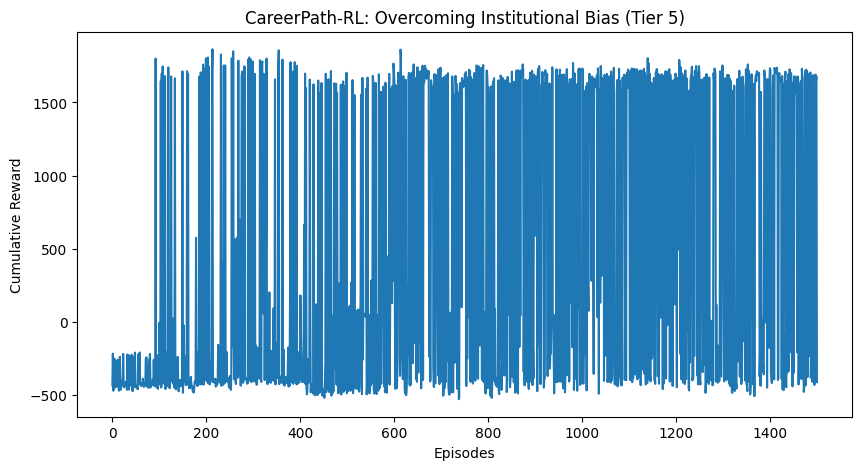


--- Optimized Career Path for Tier-5 Underdog ---
Month 1: Upskill | Skills: 12 | Collar: 0 | Savings: ₹5k
Month 2: Upskill | Skills: 24 | Collar: 0 | Savings: ₹-40k
Month 3: Network | Skills: 27 | Collar: 0 | Savings: ₹-60k
Month 4: Network | Skills: 30 | Collar: 0 | Savings: ₹-80k
Month 5: Network | Skills: 33 | Collar: 0 | Savings: ₹-100k
Month 6: Apply for Jump | Skills: 33 | Collar: 0 | Savings: ₹-115k
Month 7: Apply for Jump | Skills: 33 | Collar: 0 | Savings: ₹-130k
Month 8: Apply for Jump | Skills: 33 | Collar: 0 | Savings: ₹-145k
Month 9: Apply for Jump | Skills: 33 | Collar: 0 | Savings: ₹-160k
Month 10: Apply for Jump | Skills: 33 | Collar: 0 | Savings: ₹-175k
Month 11: Work | Skills: 33 | Collar: 0 | Savings: ₹-173k
Month 12: Work | Skills: 33 | Collar: 0 | Savings: ₹-172k
Month 13: Work | Skills: 33 | Collar: 0 | Savings: ₹-171k
Month 14: Work | Skills: 33 | Collar: 0 | Savings: ₹-170k
Month 15: Work | Skills: 33 | Collar: 0 | Savings: ₹-169k
Month 16: Work | Skills: 33 |

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm.auto import tqdm
# Redefining DQNAgent and train_agent within this cell to apply the fix,
# as per the instruction to only modify the selected cell.
# This will override the previous definitions from cell fdXzpsDZ3E89.
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQNAgent, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, x): return self.network(x)

def train_agent(env, episodes=1500):
    agent = DQNAgent(6, 4)
    optimizer = optim.Adam(agent.parameters(), lr=0.0005)
    loss_fn = nn.MSELoss()
    epsilon = 1.0
    history = []

    for ep in tqdm(range(episodes)):
        state, _ = env.reset()
        state = torch.FloatTensor(state)
        total_r = 0
        done = False
        while not done:
            action = env.action_space.sample() if np.random.rand() < epsilon else agent(state).argmax().item()
            next_s, r, done, _, _ = env.step(action)
            next_s_t = torch.FloatTensor(next_s)


            target_value = float(r) + (0.99 * torch.max(agent(next_s_t)).item() if not done else 0.0)
            target_tensor = torch.tensor(target_value, dtype=torch.float32)
            loss = loss_fn(agent(state)[action].unsqueeze(0), target_tensor.unsqueeze(0))


            optimizer.zero_grad(); loss.backward(); optimizer.step()
            state, total_r = next_s_t, total_r + r
        epsilon = max(0.1, epsilon * 0.996)
        history.append(total_r)
    return agent, history


# ==========================================
# PART 3: EXECUTION & STORYTELLING
# ==========================================
env = CareerMobilityEnv()
trained_agent, history = train_agent(env)

# Plotting the breakthrough
plt.figure(figsize=(10,5))
plt.plot(history)
plt.title("CareerPath-RL: Overcoming Institutional Bias (Tier 5)")
plt.ylabel("Cumulative Reward"); plt.xlabel("Episodes")
plt.show()

# Final Evaluation Log
state, _ = env.reset()
print("\n--- Optimized Career Path for Tier-5 Underdog ---")
for m in range(1, 40):
    action = trained_agent(torch.FloatTensor(state)).argmax().item()
    action_names = {0: "Work", 1: "Upskill", 2: "Network", 3: "Apply for Jump"}
    state, _, done, _, _ = env.step(action)
    print(f"Month {m}: {action_names[action]} | Skills: {int(state[1])} | Collar: {int(state[5])} | Savings: ₹{int(state[2])}k")
    if done: break